# Introduction to Semantic Kernel

Semantic Kernel is a lightweight, open-source development kit that lets you easily build AI agents and integrate the latest AI models into your C#, Python, or Java codebase. It serves as an efficient middleware that enables rapid delivery of enterprise-grade solutions.

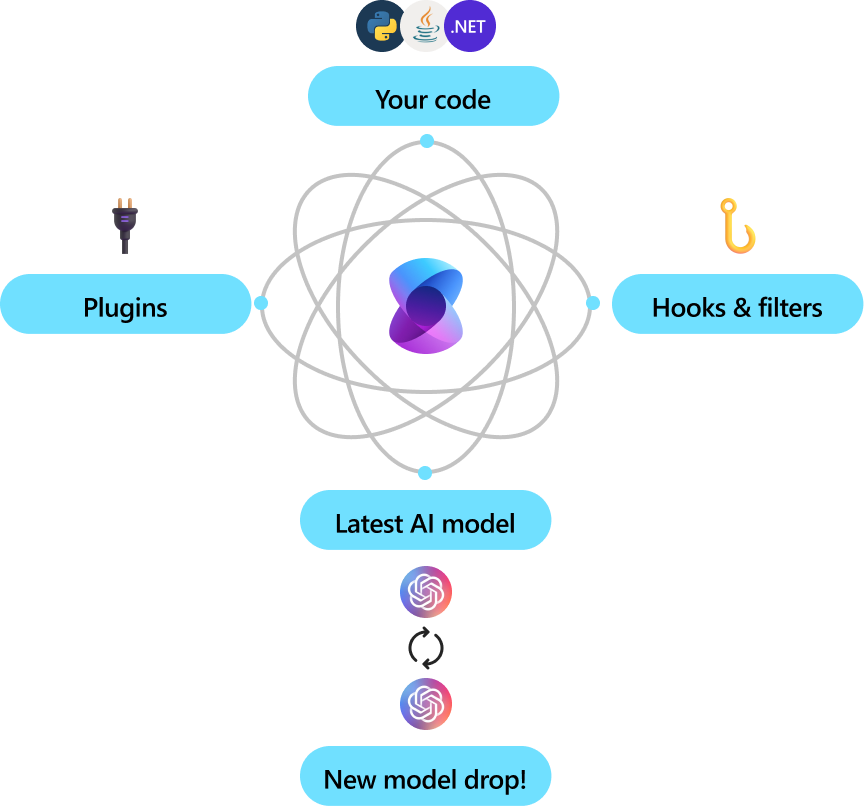

In [ ]:
# Install the required packages
!pip install -r requirements.txt


[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importing necessary libraries

## Understanding the Kernel

The kernel is at the center
Because the kernel has all of the services and plugins necessary to run both native code and AI services, it is used by nearly every component within the Semantic Kernel SDK to power your agents. This means that if you run any prompt or code in Semantic Kernel, the kernel will always be available to retrieve the necessary services and plugins.

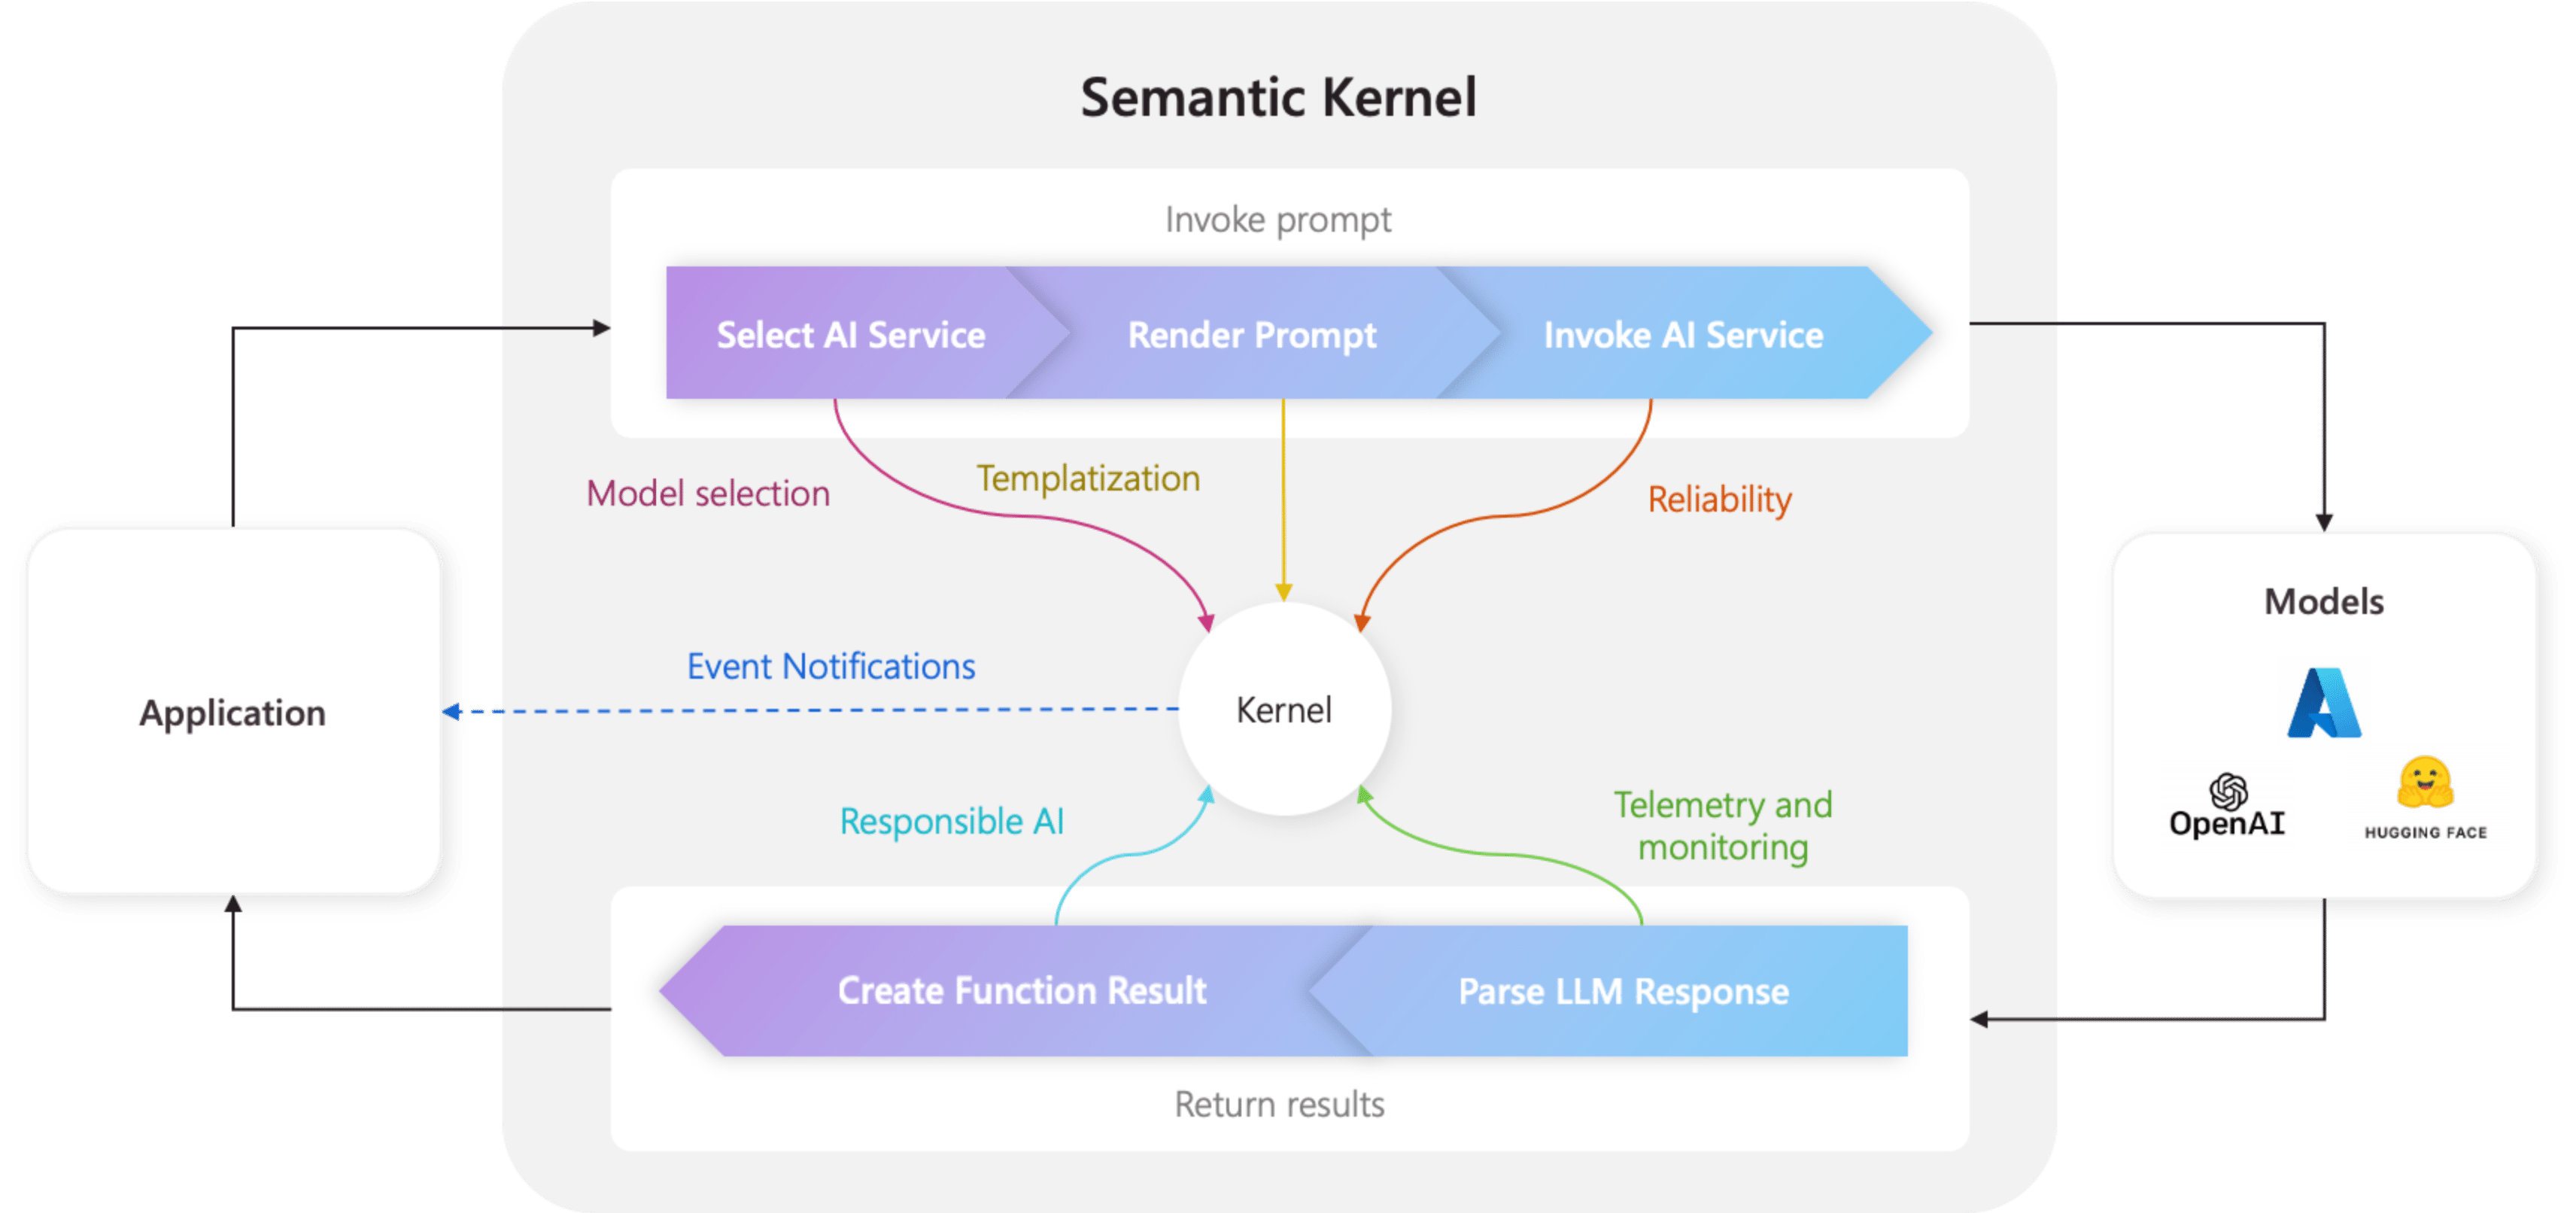
When you invoke a prompt from a kernel, the kernel will:
1. Select the best AI service to run the prompt.
2. Build the prompt using the provided prompt template.
3. Send the prompt to the AI service.
4. Receive and parse the response.
5. And finally return the response from the LLM to your application.

In [3]:
from semantic_kernel import Kernel
kernel = Kernel()

### Next we create services and plugins

#### Services
These consist of both AI services (e.g., chat completion) and other services (e.g., logging and HTTP clients) that are necessary to run your application. This was modelled after the Service Provider pattern in .NET so that we could support dependency injection across all languages.

#### Plugins
These are the components that are used by your AI services and prompt templates to perform work. AI services, for example, can use plugins to retrieve data from a database or call an external API to perform actions.

In [37]:
from semantic_kernel.connectors.ai.open_ai import AzureChatCompletion
# from semantic_kernel.core_plugins.math_plugin import MathPlugin
from semantic_kernel.core_plugins.time_plugin import TimePlugin
from semantic_kernel.utils.logging import setup_logging
import logging
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()
# Add a chat completion service to the kernel
# This example uses Azure OpenAI, but you can use any chat completion service that implements the ChatCompletionClientBase interface.
chat_completion = AzureChatCompletion(api_key=os.environ["AOAI_API_KEY"],deployment_name=os.environ["AOAI_DEPLOYMENT_NAME"], endpoint=os.environ["AOAI_ENDPOINT"],api_version=os.environ["AOAI_API_VERSION"])
kernel.add_service(chat_completion, overwrite=True)

# Add a plugin to the kernel
# kernel.add_plugin(MathPlugin(), plugin_name="Math")
kernel.add_plugin(TimePlugin(), plugin_name="Time")

# Setup logging
setup_logging()
logger = logging.getLogger("kernel")
logger.setLevel(logging.DEBUG)

### Let's create our first non-streaming chat application using SK
In any chat application having the history is important, let's create the Chat History object and see how the features created above come together

In [38]:
from semantic_kernel.connectors.ai.open_ai import OpenAIChatPromptExecutionSettings

execution_settings = OpenAIChatPromptExecutionSettings()

In [39]:
from semantic_kernel.contents.chat_history import ChatHistory
chat_history = ChatHistory()

user_questions = ["What is the capital of France?", "What is the time?"]
# Add the user question to the chat history
for question in user_questions:
    chat_history.add_user_message(question)
    # Get the answer from the kernel
    answer = await chat_completion.get_chat_message_content(chat_history=chat_history, settings=execution_settings, kernel=kernel)
    logger.info(f"Answer: {answer}")

[2025-04-02 16:21:55 - kernel:10 - INFO] Answer: The capital of France is Paris.
[2025-04-02 16:21:55 - kernel:10 - INFO] Answer: I'm unable to provide real-time information, including the current time. You might want to check a clock or a device like a smartphone or computer for the current time.


The above code does not show time, since we are not calling function even if they are available to Kernel

In [40]:
from semantic_kernel.connectors.ai.function_choice_behavior import FunctionChoiceBehavior
execution_settings = OpenAIChatPromptExecutionSettings(function_choice_behavior=FunctionChoiceBehavior.Auto())
print(execution_settings)

service_id=None extension_data={} function_choice_behavior=FunctionChoiceBehavior(enable_kernel_functions=True, maximum_auto_invoke_attempts=5, filters=None, type_=<FunctionChoiceType.AUTO: 'auto'>) ai_model_id=None frequency_penalty=None logit_bias=None max_tokens=None number_of_responses=None presence_penalty=None seed=None stop=None stream=False temperature=None top_p=None user=None store=None metadata=None response_format=None function_call=None functions=None messages=None parallel_tool_calls=None tools=None tool_choice=None structured_json_response=False stream_options=None max_completion_tokens=None reasoning_effort=None


In [42]:
from semantic_kernel.contents.chat_history import ChatHistory
chat_history = ChatHistory()

user_questions = ["What is the capital of France?", "What is the time?", "What is 2 to the power of 4?"]
# Add the user question to the chat history
for question in user_questions:
    chat_history.add_user_message(question)
    # Get the answer from the kernel
    answer = await chat_completion.get_chat_message_content(chat_history=chat_history, settings=execution_settings, kernel=kernel)
    logger.info(f"Answer: {answer}")

[2025-04-02 16:24:20 - kernel:10 - INFO] Answer: The capital of France is Paris.
[2025-04-02 16:24:21 - kernel:10 - INFO] Answer: The current time is 4:24:20 PM.
[2025-04-02 16:24:22 - kernel:10 - INFO] Answer: 2 to the power of 4 is 16.


Next we look at how do we add Vector store to Semantic Kernel